# 04 — Контролируемый ML-эксперимент

Этот notebook оставляет **идею и реализацию кандидата вам**, а рутинную часть выполняет автоматически: одинаковый validation-контракт, сравнение с baseline reference, все метрики, графики, CSV/JSON, карточка эксперимента и leaderboard в Obsidian.

<details>
<summary><strong>Как правильно начинать эксперимент — открыть инструкцию</strong></summary>

### До запуска

1. **Сформулируйте проверяемую гипотезу:** «если изменить X, то метрика Y изменится не менее чем на Z, потому что…».
2. **Меняйте один основной фактор.** Иначе вы не узнаете, что именно дало результат.
3. **Заранее зафиксируйте критерий успеха и guardrails.** Не подгоняйте их после просмотра score.
4. **Сохраните тот же dataset, target, split и набор метрик**, что у baseline. Notebook делает это автоматически.
5. **Назначьте новый `EXPERIMENT_ID` и `RUN_NAME`** для нового смысла эксперимента.

### Чего избегать

- не оценивайте идеи на inference/test и не подбирайте по нему параметры;
- не меняйте одновременно модель, признаки, preprocessing и validation;
- не выбирайте «красивый» fold или лучший случайный seed;
- не делайте preprocessing до CV — он должен быть внутри `Pipeline`;
- не перезаписывайте исходные признаки в `experiment_frame`: создавайте новый столбец или transformer;
- не объявляйте победой микроскопический прирост без проверки разброса folds и guardrails;
- не удаляйте отрицательные эксперименты: они предотвращают повторение тех же ошибок;
- не повышайте baseline автоматически: сначала заполните ручной вывод и решение.

### Рабочий цикл

1. Заполните `src/ml_project/experiment_config.py` **до просмотра результата**.
2. В первой пользовательской зоне при необходимости создайте новые признаки/группы.
3. Во второй пользовательской зоне создайте `candidate_models`.
4. Запустите автоматические ячейки ниже: reference и кандидаты будут проверены на одинаковых folds.
5. Откройте созданную карточку `EXP-xxx`, объясните результат и примите решение.
6. После решения измените `DECISION` в конфиге и повторите только ячейку сохранения/синхронизации.

</details>

> [!important]
> Ячейки с пометкой **ПОЛЬЗОВАТЕЛЬСКАЯ ЗОНА** — место для вашей экспериментальной идеи. Графики, таблицы и Markdown вручную собирать не нужно.


## 0. Перед стартом

- [ ] Baseline уже сохранён и понятен.
- [ ] В `experiment_config.py` заполнены гипотеза, одно изменение и критерий успеха.
- [ ] Новый эксперимент получил уникальные `EXPERIMENT_ID` и `RUN_NAME`.
- [ ] Вы не смотрите на inference/test для принятия решения.


In [11]:
from pathlib import Path
from dataclasses import replace
import copy
import importlib
import sys

from IPython.display import display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").exists() and (candidate / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import DataCatalog
import ml_project.config as project_config
import ml_project.baseline_config as baseline_config
import ml_project.experiment_config as experiment_config
import ml_project.baseline as baseline_tools
import ml_project.experiment as experiment_tools

print(f"Корень проекта: {PROJECT_ROOT}")


Корень проекта: D:\Anton_ML\obsidian\Titanik-ML-project


## 1. Перечитать конфиги

После изменения `config.py`, `baseline_config.py` или `experiment_config.py` повторно запустите эту ячейку и все ячейки ниже. Restart kernel не нужен.


In [26]:
project_config = importlib.reload(project_config)
baseline_config = importlib.reload(baseline_config)
experiment_config = importlib.reload(experiment_config)
baseline_tools = importlib.reload(baseline_tools)
experiment_tools = importlib.reload(experiment_tools)

DATASETS = project_config.DATASETS
FEATURE_GROUPS = project_config.FEATURE_GROUPS
INFERENCE_DATASET = project_config.INFERENCE_DATASET
KEY = project_config.KEY
RAW_DIR = project_config.RAW_DIR
TARGET = project_config.TARGET
TRAIN_DATASET = project_config.TRAIN_DATASET

baseline_settings = baseline_tools.settings_from_module(baseline_config)
experiment_settings = experiment_tools.settings_from_module(experiment_config)
baseline_tools.validate_baseline_settings(baseline_settings)
experiment_tools.validate_settings(experiment_settings)
display(experiment_tools.settings_report(experiment_settings))
print("Конфиги baseline и эксперимента прошли проверку.")


,section,parameter,value
0,identity,EXPERIMENT_ID,EXP-002
1,identity,EXPERIMENT_TITLE,"Заполнение пропусков Age с помощью ""title"" and..."
2,pre-registration,HYPOTHESIS,"if я заполню возраст более точно, then accura..."
3,pre-registration,CHANGE_DESCRIPTION,новый способ заполнения пустот
4,pre-registration,SUCCESS_CRITERION,accuracy
5,comparison,REFERENCE_MODEL,baseline_reference
6,comparison,PRIMARY_CANDIDATE,candidate
7,comparison,DECISION,pending
8,write,RUN_NAME,exp_002_v1
9,write,SAVE_ARTIFACTS,True


Конфиги baseline и эксперимента прошли проверку.


## 2. Загрузить неизменяемый train-контракт

Inference загружается только для проверки схемы и не участвует в оценке.


In [14]:
catalog = DataCatalog(PROJECT_ROOT, RAW_DIR, DATASETS)
catalog.validate()
train = catalog.load(TRAIN_DATASET)
inference = catalog.load(INFERENCE_DATASET) if INFERENCE_DATASET else None

train_file = catalog.file_report().set_index("dataset").loc[TRAIN_DATASET]
dataset_version = str(train_file["sha256"])
print(f"Train: {train.shape[0]} строк × {train.shape[1]} столбцов")
print("Dataset SHA-256:", dataset_version)


Train: 891 строк × 12 столбцов
Dataset SHA-256: 7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f


## 3. Автоматически восстановить baseline reference

Reference строится из `baseline_config.py`. Не копируйте baseline score из старого CSV: модель пересчитывается на тех же folds вместе с кандидатами.


In [15]:
reference_plan = baseline_tools.resolve_feature_plan(
    train, FEATURE_GROUPS, target=TARGET, key=KEY, settings=baseline_settings,
)
if inference is not None:
    baseline_tools.validate_inference_schema(
        inference, reference_plan, strict=baseline_settings.require_inference_features,
    )
reference_data = baseline_tools.prepare_training_data(
    train, target=TARGET, plan=reference_plan, settings=baseline_settings,
)
scoring_plan = baseline_tools.resolve_scoring_plan(PROJECT_ROOT, baseline_settings)
cv, resolved_cv_strategy = baseline_tools.build_cv_splitter(
    baseline_settings, reference_data.y,
)
cv_description = baseline_tools.cv_protocol_description(
    baseline_settings, resolved_cv_strategy,
)
reference_preprocessor = baseline_tools.build_tabular_preprocessor(
    baseline_settings, reference_plan,
)
reference_pipeline = baseline_tools.build_model_pipeline(
    reference_preprocessor,
    baseline_tools.build_simple_estimator(baseline_settings),
)
print("Reference:", experiment_settings.reference_model)
print("Validation:", cv_description)
display(scoring_plan.to_frame())


Reference: baseline_reference
Validation: stratified_kfold(n_splits=5, shuffle=True, seed=42)


,role,report_name,sklearn_scorer,direction
0,primary,accuracy,accuracy,maximize
1,secondary,Balanced accuracy,balanced_accuracy,maximize
2,secondary,Precision,precision,maximize
3,secondary,Recall,recall,maximize
4,secondary,F1,f1,maximize
5,secondary,ROC-AUC,roc_auc,maximize


## 4. ПОЛЬЗОВАТЕЛЬСКАЯ ЗОНА A — данные и признаки

Если эксперимент касается только модели или её параметров, **оставьте ячейку как есть**.

Если создаёте новый признак:

1. создайте его в `experiment_frame` под новым именем;
2. добавьте имя ровно в одну группу `experiment_feature_groups`;
3. при необходимости измените `candidate_settings` через `dataclasses.replace`;
4. не изменяйте target, строки и исходные baseline-столбцы.


In [32]:
experiment_frame = train.copy()
experiment_feature_groups = copy.deepcopy(FEATURE_GROUPS)
candidate_settings = baseline_settings

experiment_frame["Title"] = (
    experiment_frame["Name"]
    .astype("string")
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)
experiment_feature_groups["ignored"].append("Title")
display(
    experiment_frame[
        ["PassengerId", "Name", "Title", "Sex", "Age", "Pclass"]
    ].head(20)
)

# >>> ВАШ ЭКСПЕРИМЕНТ С ПРИЗНАКАМИ НАЧИНАЕТСЯ ЗДЕСЬ
# Пример формы (не активный рецепт):
# experiment_frame["new_feature"] = ...
# experiment_feature_groups["numeric"].append("new_feature")
# candidate_settings = replace(
#     baseline_settings,
#     include_features=(*baseline_settings.include_features, "new_feature"),
# )
# <<< КОНЕЦ ПОЛЬЗОВАТЕЛЬСКОЙ ЗОНЫ A


,PassengerId,Name,Title,Sex,Age,Pclass
0,1,"Braund, Mr. Owen Harris",Mr,male,22.0,3
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,female,38.0,1
2,3,"Heikkinen, Miss. Laina",Miss,female,26.0,3
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,female,35.0,1
4,5,"Allen, Mr. William Henry",Mr,male,35.0,3
5,6,"Moran, Mr. James",Mr,male,NaN,3
6,7,"McCarthy, Mr. Timothy J",Mr,male,54.0,1
7,8,"Palsson, Master. Gosta Leonard",Master,male,2.0,3
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,female,27.0,3
9,10,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,female,14.0,2


In [33]:
title_report = (
    experiment_frame["Title"]
    .value_counts(dropna=False)
    .rename_axis("Title")
    .reset_index(name="rows")
)

title_report["share"] = (
    title_report["rows"] / len(experiment_frame)
)

display(
    title_report.style.format({
        "share": "{:.2%}",
    })
)
main_titles = {"Mr", "Mrs", "Miss", "Master"}

# Сохраняем исходные титулы во временной переменной для проверки
original_title = experiment_frame["Title"].copy()

rare_title_mask = ~experiment_frame["Title"].isin(main_titles)

# Редкие мужские титулы → Mr
experiment_frame.loc[
    rare_title_mask & experiment_frame["Sex"].eq("male"),
    "Title",
] = "Mr"

# Редкие женские титулы → Mrs
experiment_frame.loc[
    rare_title_mask & experiment_frame["Sex"].eq("female"),
    "Title",
] = "Mrs"
display(
    experiment_frame["Title"]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)
experiment_feature_groups["ignored"].append("Title")

,Title,rows,share
0,Mr,517,58.02%
1,Miss,182,20.43%
2,Mrs,125,14.03%
3,Master,40,4.49%
4,Dr,7,0.79%
5,Rev,6,0.67%
6,Major,2,0.22%
7,Mlle,2,0.22%
8,Col,2,0.22%
9,Don,1,0.11%


,rows
Title,
Mr,537
Miss,182
Mrs,132
Master,40


In [34]:
age_group_report = (
    experiment_frame
    .groupby(["Title", "Pclass"], dropna=False)
    .agg(
        rows=("PassengerId", "size"),
        age_known=("Age", "count"),
        age_missing=("Age", lambda values: values.isna().sum()),
        age_median=("Age", "median"),
    )
    .reset_index()
    .sort_values(["Title", "Pclass"])
)

display(age_group_report)


,Title,Pclass,rows,age_known,age_missing,age_median
0,Master,1,3,3,0,4.0
1,Master,2,9,9,0,1.0
2,Master,3,28,24,4,4.0
3,Miss,1,46,45,1,30.0
4,Miss,2,34,32,2,24.0
5,Miss,3,102,69,33,18.0
6,Mr,1,119,98,21,42.0
7,Mr,2,99,90,9,31.0
8,Mr,3,319,229,90,26.0
9,Mrs,1,48,40,8,39.5


## 5. Автоматически проверить candidate feature contract

Ячейка остановится, если были потеряны строки, изменён target или перезаписан исходный baseline-признак.


In [35]:
candidate_plan = baseline_tools.resolve_feature_plan(
    experiment_frame,
    experiment_feature_groups,
    target=TARGET,
    key=KEY,
    settings=candidate_settings,
)
prepared = experiment_tools.prepare_experiment_data(
    reference_data, experiment_frame, target=TARGET,
)
candidate_preprocessor = baseline_tools.build_tabular_preprocessor(
    candidate_settings, candidate_plan,
)
display(candidate_plan.to_frame())
print("Candidate matrix:", prepared.X.shape)


,feature,config_group,model_role,status,reason
0,Age,numeric,numeric,used,
1,Fare,numeric,numeric,used,
2,SibSp,count,numeric,used,
3,Parch,count,numeric,used,
4,Sex,categorical,categorical,used,
5,Cabin,categorical,—,excluded,explicit EXCLUDE_FEATURES
6,Embarked,categorical,categorical,used,
7,Pclass,ordinal,categorical,used,
8,Name,text,—,excluded,group 'text' is not enabled for this baseline
9,PassengerId,identifier,—,excluded,project key / identifier


Candidate matrix: (891, 12)


## 6. ПОЛЬЗОВАТЕЛЬСКАЯ ЗОНА B — кандидаты

Создайте один или несколько полных sklearn-совместимых pipelines. Ключ основного кандидата должен совпадать с `PRIMARY_CANDIDATE`.

Обычная форма:

```python
from sklearn.some_module import SomeEstimator

estimator = SomeEstimator(...)
candidate_models["candidate"] = baseline_tools.build_model_pipeline(
    candidate_preprocessor,
    estimator,
)
```

Все preprocessing-шаги должны находиться внутри pipeline. Если логика стала повторно используемой, перенесите её из notebook в `src/ml_project`.


In [36]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline

from ml_project.transformers import (
    AgeByTitlePclassImputer,
)

candidate_models = {}

candidate_estimator = (
    baseline_tools.build_simple_estimator(
        candidate_settings
    )
)

candidate_models[
    experiment_settings.primary_candidate
] = Pipeline(
    steps=[
        (
            "age_imputer",
            AgeByTitlePclassImputer(
                age_column="Age",
                title_column="Title",
                class_column="Pclass",
            ),
        ),
        (
            "preprocess",
            clone(candidate_preprocessor),
        ),
        (
            "model",
            candidate_estimator,
        ),
    ]
)


# >>> ВАШ ЭКСПЕРИМЕНТ С МОДЕЛЬЮ НАЧИНАЕТСЯ ЗДЕСЬ
# from sklearn... import ...
# candidate_estimator = ...
# candidate_models[experiment_settings.primary_candidate] = (
#     baseline_tools.build_model_pipeline(
#         candidate_preprocessor,
#         candidate_estimator,
#     )
# )
# Можно добавить дополнительные кандидаты с уникальными именами.
# <<< КОНЕЦ ПОЛЬЗОВАТЕЛЬСКОЙ ЗОНЫ B


In [37]:
candidate_pipeline = candidate_models[
    experiment_settings.primary_candidate
]

display(candidate_pipeline)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('age_imputer', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,age_column,'Age'
,title_column,'Title'
,class_column,'Pclass'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have id

## 7. Автоматически собрать сравнение

Reference нельзя заменить кандидатом. Все модели оцениваются одним scorer-набором и CV-контрактом.


In [38]:
experiment_tools.validate_model_contract(
    candidate_models, experiment_settings,
)
models = {
    experiment_settings.reference_model: reference_pipeline,
    **candidate_models,
}
print("Сравниваемые модели:", ", ".join(models))


Сравниваемые модели: baseline_reference, candidate


## 8. Выполнить cross-validation

До этой ячейки гипотеза и критерий успеха уже должны быть зафиксированы в конфиге.


In [39]:
evaluation = baseline_tools.evaluate_models_cv(
    models,
    prepared,
    cv=cv,
    scoring=scoring_plan,
    settings=baseline_settings,
)
comparison = experiment_tools.comparison_summary(
    evaluation,
    scoring_plan,
    reference_model=experiment_settings.reference_model,
)
display(
    comparison[
        ["model", "metric", "direction", "mean ± std", "reference_mean", "improvement"]
    ].round(4)
)


,model,metric,direction,mean ± std,reference_mean,improvement
0,baseline_reference,accuracy,maximize,0.7969 ± 0.0163,0.7969,0.0000
1,baseline_reference,Balanced accuracy,maximize,0.7788 ± 0.0174,0.7788,0.0000
2,baseline_reference,Precision,maximize,0.7547 ± 0.0374,0.7547,0.0000
3,baseline_reference,Recall,maximize,0.7016 ± 0.0448,0.7016,0.0000
4,baseline_reference,F1,maximize,0.7258 ± 0.0233,0.7258,0.0000
5,baseline_reference,ROC-AUC,maximize,0.8514 ± 0.0251,0.8514,0.0000
6,candidate,accuracy,maximize,0.8036 ± 0.0163,0.7969,0.0067
7,candidate,Balanced accuracy,maximize,0.7832 ± 0.0193,0.7788,0.0044
8,candidate,Precision,maximize,0.7710 ± 0.0285,0.7547,0.0163
9,candidate,Recall,maximize,0.6958 ± 0.0404,0.7016,-0.0058


## 9. Автоматически построить график каждой метрики

Положительная `improvement` означает улучшение независимо от направления метрики. Графики показывают значения моделей по одинаковым validation-folds.


Метрика: accuracy


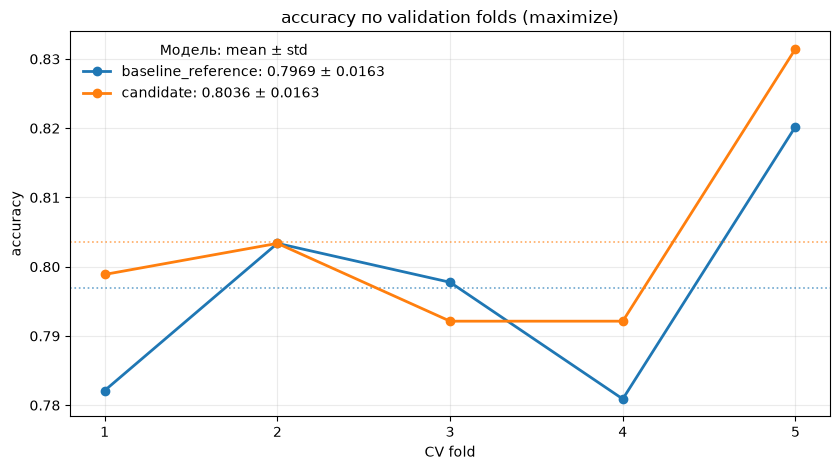

Метрика: Balanced accuracy


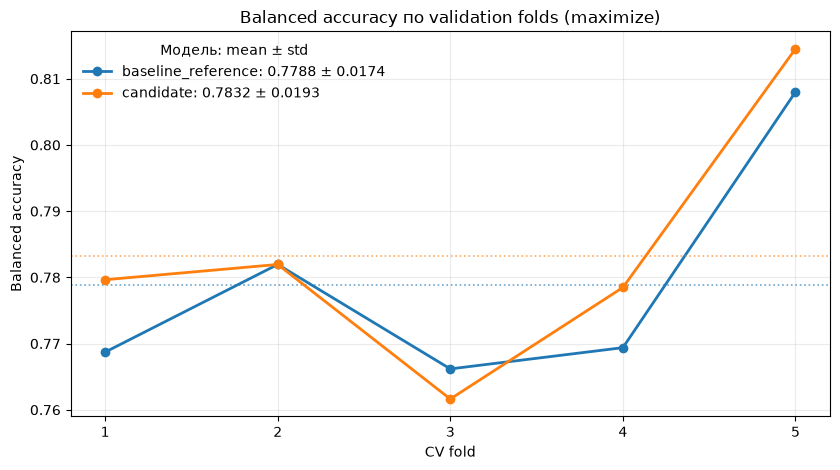

Метрика: Precision


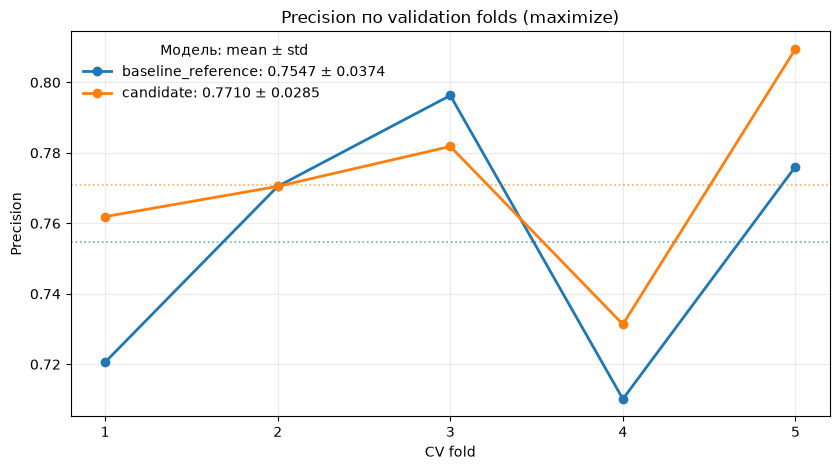

Метрика: Recall


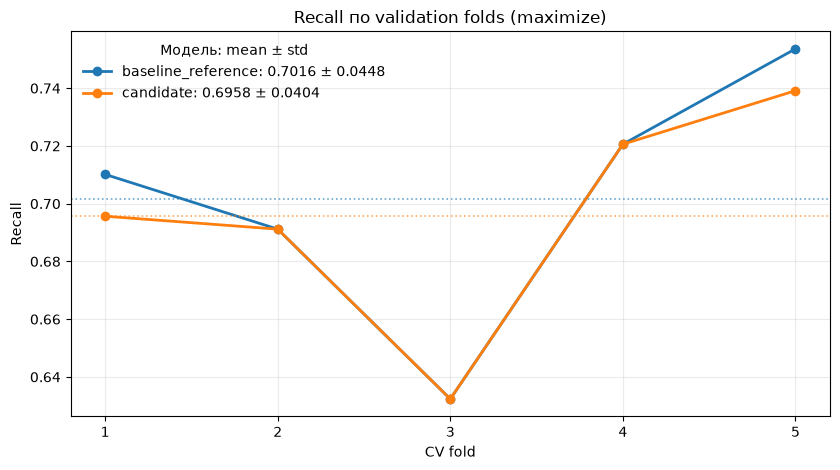

Метрика: F1


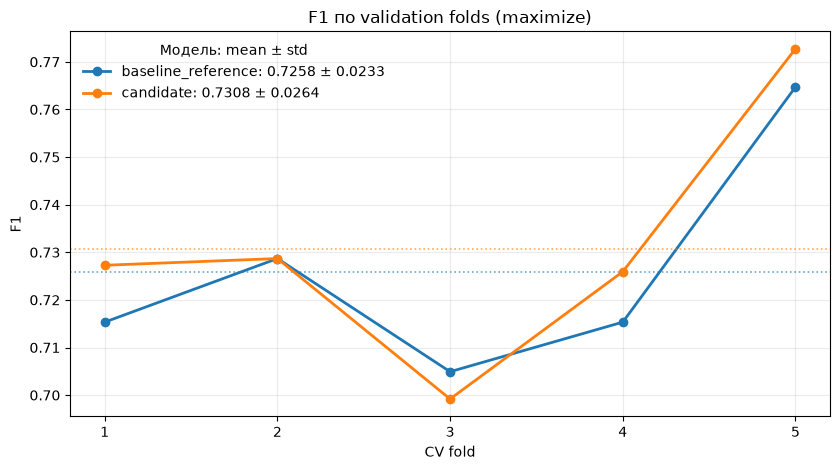

Метрика: ROC-AUC


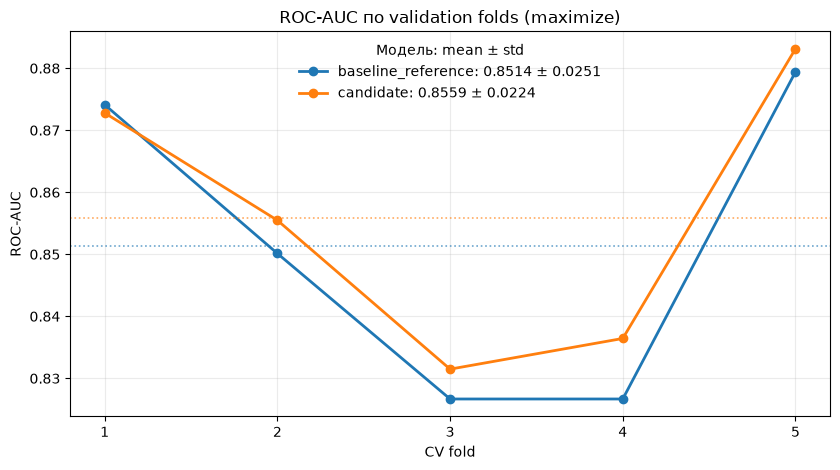

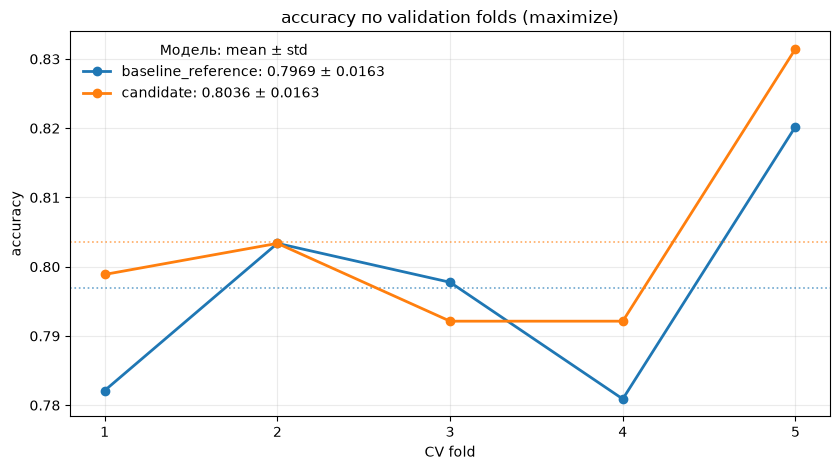

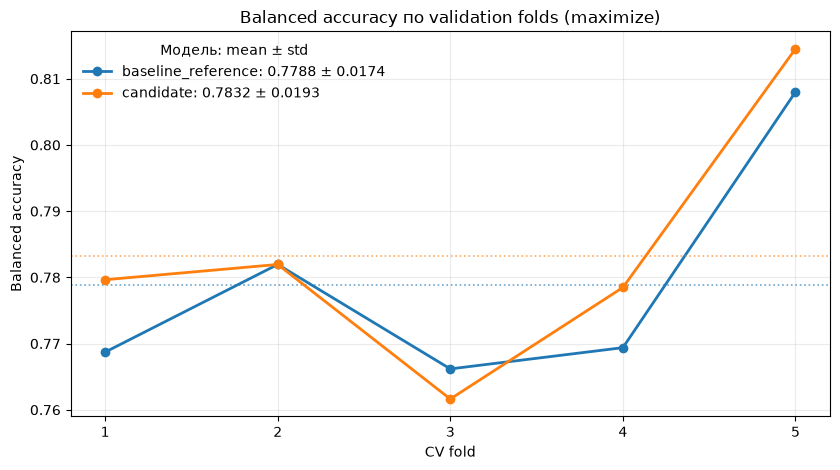

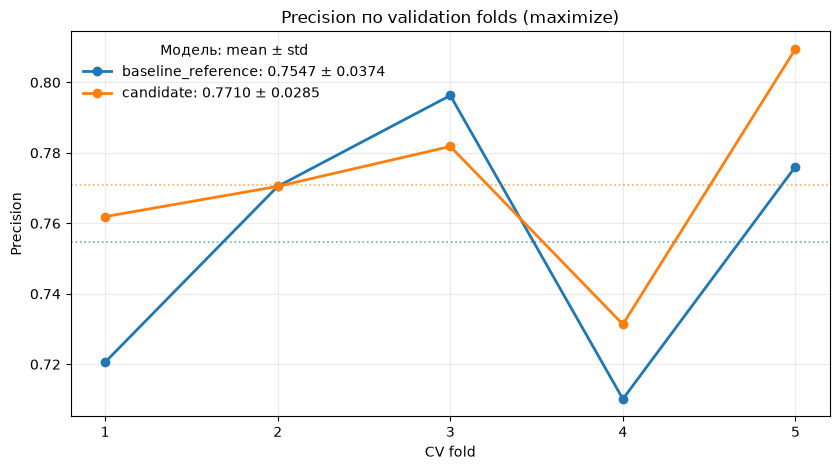

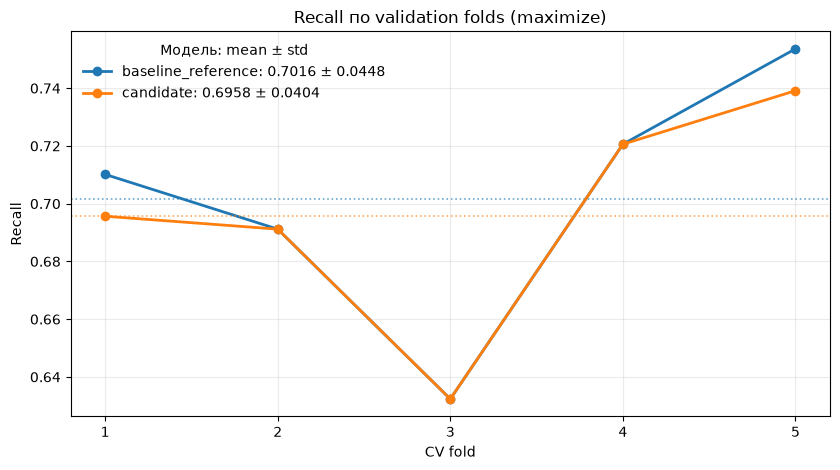

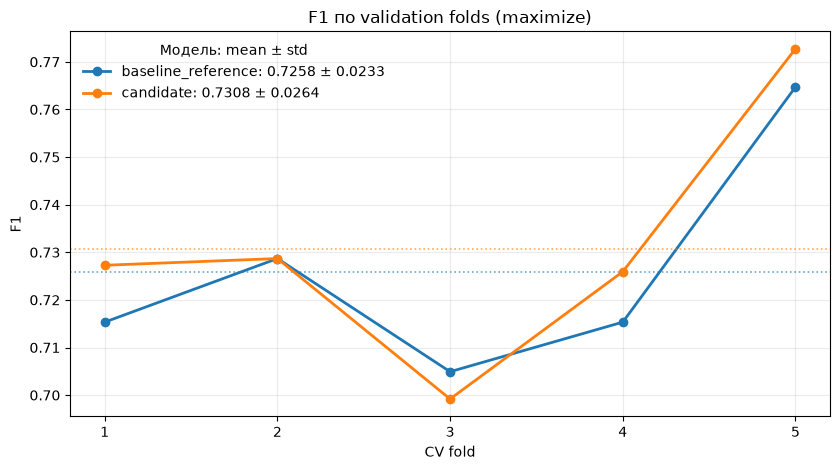

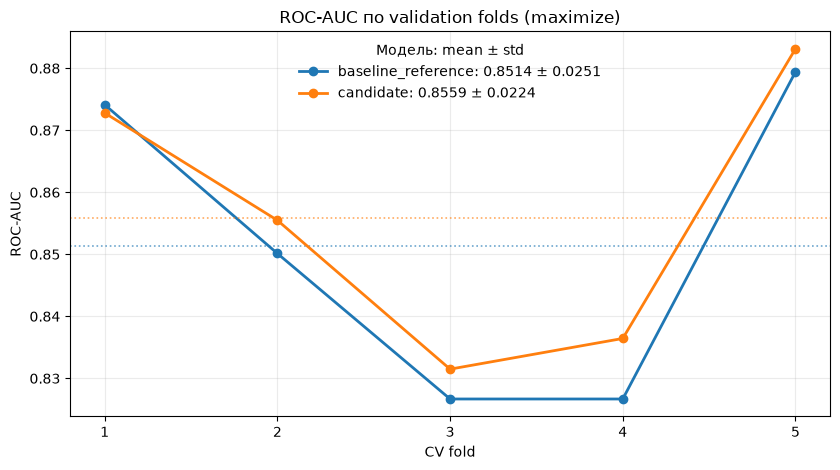

In [40]:
metric_figures = baseline_tools.build_metric_figures(
    evaluation, scoring_plan,
)
for metric_key, figure in metric_figures.items():
    print(f"Метрика: {scoring_plan.labels[metric_key]}")
    display(figure)


## 10. Автоматически сохранить и синхронизировать Obsidian

Ячейка:

- безопасно перезаписывает известные файлы того же `RUN_NAME`;
- сохраняет CSV, JSON, PNG и при необходимости финальную модель;
- создаёт/обновляет карточку эксперимента;
- встраивает туда графики и таблицы по folds;
- обновляет последний эксперимент и leaderboard в `docs/05_experiments.md`;
- сохраняет историю в `experiments/results.csv`.

Ручной анализ вне auto-маркеров не удаляется.


In [41]:
saved_run = None
write_requested = (
    experiment_settings.save_artifacts
    or experiment_settings.save_final_model
)
if write_requested:
    saved_run = experiment_tools.save_experiment_run(
        PROJECT_ROOT,
        experiment_settings,
        baseline_settings,
        evaluation,
        candidate_plan,
        scoring_plan,
        dataset_version=dataset_version,
        cv_description=cv_description,
        models=models,
        data=prepared,
        metric_figures=metric_figures,
    )
    print("Артефакты:", saved_run.run_dir.relative_to(PROJECT_ROOT))
else:
    print("Запись артефактов отключена.")

if experiment_settings.sync_experiment_note:
    if saved_run is None:
        print("Карточка не обновлена: сначала включите SAVE_ARTIFACTS.")
    else:
        updated_note = experiment_tools.sync_experiment_note(
            PROJECT_ROOT,
            experiment_settings,
            evaluation,
            scoring_plan,
            saved_run,
            dataset_version=dataset_version[:12] + "…",
            cv_description=cv_description,
        )
        print("Карточка:", experiment_settings.experiment_note, updated_note)

if experiment_settings.sync_docs:
    updated_docs = experiment_tools.sync_experiment_docs(
        PROJECT_ROOT,
        experiment_settings,
        evaluation,
        scoring_plan,
        dataset_version=dataset_version[:12] + "…",
    )
    print("Docs/registry:", updated_docs)


Артефакты: artifacts\experiments\exp_002_v1
Карточка: experiments\EXP-002 AGE_Experiment.md ['experiment-report']
Docs/registry: {'registry': 'experiments/results.csv', 'blocks': ['latest-experiment', 'experiment-leaderboard']}


## 11. Ручной вывод и решение

1. Откройте карточку из `EXPERIMENT_NOTE`.
2. Объясните результат, а не только перепишите score.
3. Проверьте стабильность folds, guardrails, leakage и практическую величину эффекта.
4. Выберите outcome: `adopt / reject / iterate / inconclusive`.
5. Измените `DECISION` в `experiment_config.py`, перезапустите ячейку **1**, затем только эту ячейку сохранения.
6. Для следующей идеи назначьте новые `EXPERIMENT_ID`, `EXPERIMENT_NOTE` и `RUN_NAME`.

> [!warning]
> Решение `adopt` не обязано немедленно заменять baseline. Сначала убедитесь, что результат сопоставим, устойчив и воспроизводим.
